In [4]:
# Llama-3.2 is gated. Store a Kaggle secret named HF_TOKEN.
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

try:
    token = UserSecretsClient().get_secret('HF_TOKEN')
    login(token=token)
    print('Hugging Face login: OK')
except Exception as exc:
    print('HF login was not completed automatically:', exc)
    print('If the model is already cached and accessible, you can continue.')


Hugging Face login: OK


In [5]:
import torch
from transformers import AutoModelForCausalLM
import matplotlib.pyplot as plt

model = AutoModelForCausalLM.from_pretrained('meta-llama/Llama-3.2-1B',)

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Layer 0: minimum rank = 62


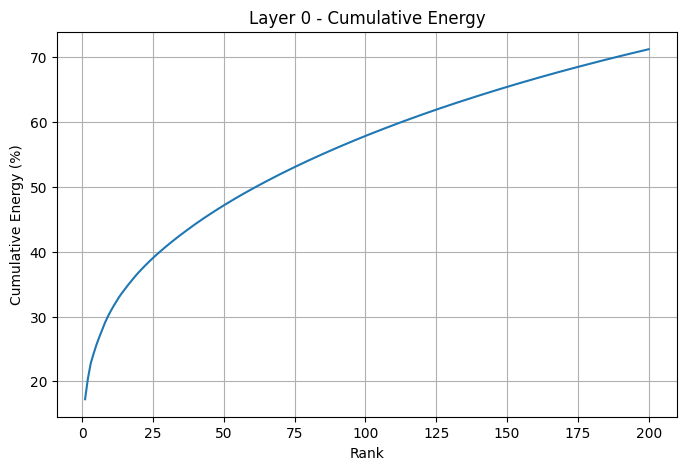

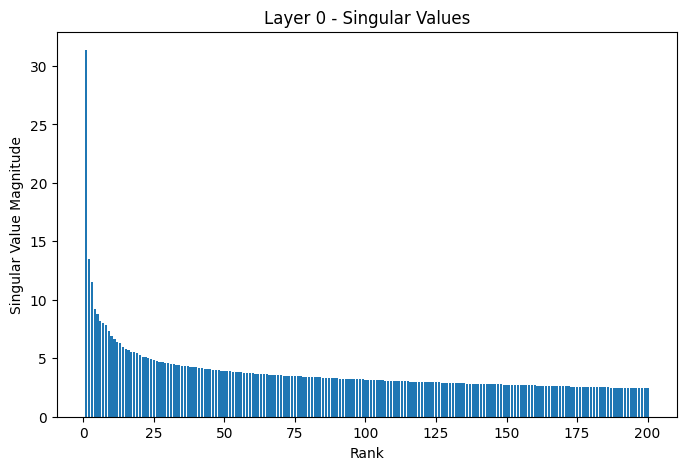

Layer 7: minimum rank = 120


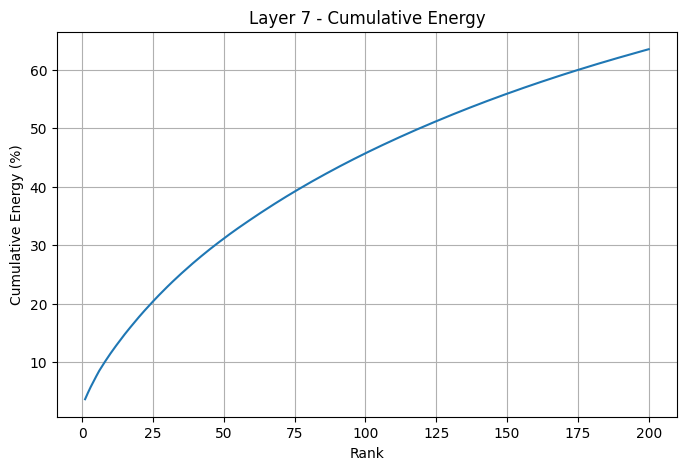

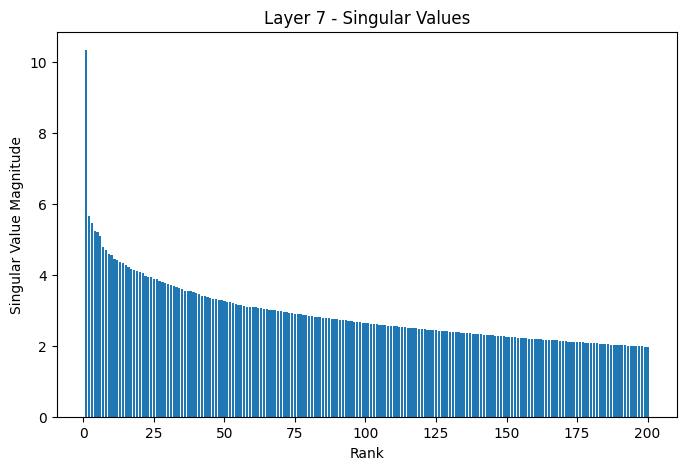

Layer 15: minimum rank = 84


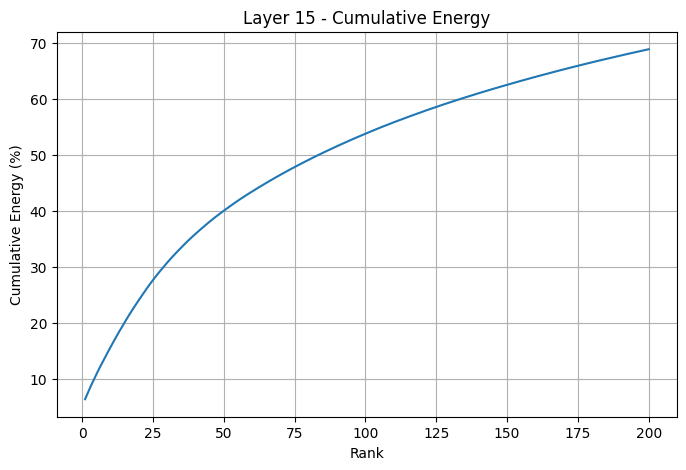

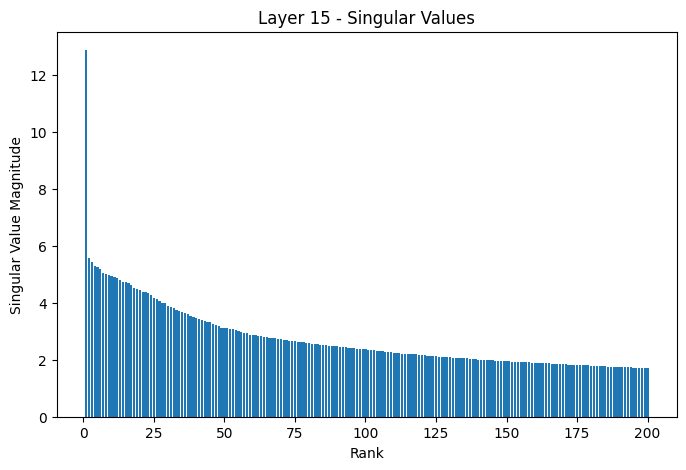

In [6]:
# TODO for Question 4
"""

Hint:
# Analyze the weights of the query projection layer (q_proj) where layer = k
 q_weight = model.model.layers[k].self_attn.q_proj.weight.detach()

# Apply SVD to decompose the weight matrix into U (left singular vectors), S (singular values), and V (right singular vectors).
 U, S, Vh = torch.linalg.svd(q_weight.float(), full_matrices=False)

# Compute the retained energy ratio (Cumulative energy) of each singular value.
energy_ratios = torch.cumsum(S ** 2, dim=0) / torch.sum(S ** 2) * 100
"""

for k in [0, 7, 15]:
    q_weight = model.model.layers[k].self_attn.q_proj.weight.detach()

    U, S, Vh = torch.linalg.svd(q_weight.float(), full_matrices=False)

    energy_ratios = torch.cumsum(S ** 2, dim=0) / torch.sum(S ** 2) * 100

    S_200 = S[:200]
    energy_200 = energy_ratios[:200]

    rank = torch.where(energy_ratios >= 50)[0][0].item() + 1

    print(f"Layer {k}: minimum rank = {rank}")

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 201), energy_200.cpu().numpy())
    plt.xlabel("Rank")
    plt.ylabel("Cumulative Energy (%)")
    plt.title(f"Layer {k} - Cumulative Energy")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.bar(range(1, 201), S_200.cpu().numpy())
    plt.xlabel("Rank")
    plt.ylabel("Singular Value Magnitude")
    plt.title(f"Layer {k} - Singular Values")
    plt.show()